In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import Callback
from tensorflow.keras import regularizers

In [7]:
# *** IMPORTANT: Replace this mock data block with your actual data loading ***
try:
    # Attempt to load the data using the relative path from the notebook's name
    # The user should ensure 'ex2data2.csv' is available in the run environment.
    df = pd.read_csv('D:/Machine Learning/Day-9_Logistic Regression Part 2/ex2data2.csv')
    print("Attempting to load data from 'ex2data2.csv'...")
except FileNotFoundError:
    # Create mock data if the CSV file is not found (for demonstration/testing)
    print("WARNING: Data file 'ex2data2.csv' not found. Using mock data for demonstration.")
    np.random.seed(42)
    # Generate 118 samples with 2 features and a binary target
    X_mock = np.random.uniform(-1, 1, (118, 2))
    y_mock = (X_mock[:, 0]**2 + X_mock[:, 1]**2 > 0.5).astype(int)
    df = pd.DataFrame(X_mock, columns=['x1', 'x2'])
    df['y'] = y_mock

Attempting to load data from 'ex2data2.csv'...


In [8]:
# Separate features (X) and target (y)
X = df[['x1','x2']].values
y = df['y'].values
print(f"Original Data Shape: X={X.shape}, y={y.shape}")

Original Data Shape: X=(118, 2), y=(118,)


In [64]:
# --- 2. FEATURE ENGINEERING (Polynomial Features) ---

# Replicate the PolynomialFeatures transformation from the scikit-learn notebook (degree=4)
degree = 5
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X)
print(f"Polynomial Features Shape (equivalent to X_poly in notebook): {X_poly.shape}")

Polynomial Features Shape (equivalent to X_poly in notebook): (118, 21)


In [65]:
# --- 3. DATA SPLITTING ---

# Split the dataset into training and testing sets (test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, 
                                                    test_size=0.2, 
                                                    random_state=42)
print(f"Train/Test Shapes: X_train={X_train.shape}, X_test={X_test.shape}")

Train/Test Shapes: X_train=(94, 21), X_test=(24, 21)


In [66]:
# --- 4. TENSORFLOW/KERAS MODEL DEFINITION ---

# The original MLPClassifier architecture: 
# hidden_layer_sizes=(25, 25), activation='relu'

input_dim = X_train.shape[1] # 15 features
lambda_l2 = 0.001 
model = tf.keras.Sequential([
    # Input Layer is implicitly defined by the shape of the first Dense layer
    
    # Hidden Layer 1: 25 units, ReLU activation
    tf.keras.layers.Dense(40, activation='relu', input_shape=(input_dim,), name='Hidden_Layer_1',  kernel_regularizer=regularizers.l2(lambda_l2)),
    
    # Hidden Layer 2: 25 units, ReLU activation
    tf.keras.layers.Dense(25, activation='relu', name='Hidden_Layer_2',  kernel_regularizer=regularizers.l2(lambda_l2)),
    
    # Output Layer: 1 unit with Sigmoid activation for Binary Classification
    tf.keras.layers.Dense(1, activation='sigmoid', name='Output_Layer', kernel_regularizer=regularizers.l2(lambda_l2))
])

C:\Users\thein\anaconda3\envs\Data\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
# --- 5. MODEL COMPILATION ---

# Match the 'adam' solver. For binary classification, use binary_crossentropy loss.
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)               │ (None, 40)                  │             880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer_2 (Dense)               │ (None, 25)                  │           1,025 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Layer (Dense)                 │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,931 (7.54 KB)

 Trainable params: 1,931 (7.54 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# Custom callback to print every N epochs
class EpochPrintCallback(Callback):
    def __init__(self, print_every):
        super().__init__()
        self.print_every = print_every

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.print_every == 0:
            print(f"Epoch {epoch + 1}: loss = {logs['loss']:.4f}, accuracy = {logs.get('accuracy', 'N/A')}")

In [68]:
# 
# --- 6. MODEL TRAINING ---

# The original max_iter=10000 is equivalent to 10000 epochs in Keras.
# Using a slightly lower number like 2000 for faster execution in a notebook environment, 
# but the user can increase it to 10000 to match the exact scikit-learn setup.
EPOCHS = 2000 
BATCH_SIZE = 32 # Default batch size for most Keras setups

print(f"\nStarting training for {EPOCHS} epochs...")
history = model.fit(X_train, y_train, 
                    epochs=EPOCHS, 
                    batch_size=BATCH_SIZE,
                    verbose=0, # Set to 1 to see epoch progress
                    callbacks=[EpochPrintCallback(100)] 
                   )

print("Training finished.")


Starting training for 2000 epochs...
Epoch 100: loss = 0.3921, accuracy = 0.8191489577293396
Epoch 200: loss = 0.3665, accuracy = 0.8510638475418091
Epoch 300: loss = 0.3564, accuracy = 0.8510638475418091
Epoch 400: loss = 0.3489, accuracy = 0.8617021441459656
Epoch 500: loss = 0.3448, accuracy = 0.8617021441459656
Epoch 600: loss = 0.3396, accuracy = 0.8617021441459656
Epoch 700: loss = 0.3346, accuracy = 0.8723404407501221
Epoch 800: loss = 0.3300, accuracy = 0.8723404407501221
Epoch 900: loss = 0.3262, accuracy = 0.8723404407501221
Epoch 1000: loss = 0.3233, accuracy = 0.8723404407501221
Epoch 1100: loss = 0.3217, accuracy = 0.8936170339584351
Epoch 1200: loss = 0.3169, accuracy = 0.8723404407501221
Epoch 1300: loss = 0.3141, accuracy = 0.8829787373542786
Epoch 1400: loss = 0.3125, accuracy = 0.8936170339584351


KeyboardInterrupt: 

In [43]:
# --- 7. EVALUATION ---

# Get predictions on the test set
# Keras model output is probability (0 to 1), so we convert it to binary classes (0 or 1)
y_prob = model.predict(X_test, verbose=0)
y_pred_binary = (y_prob > 0.5).astype("int32")

# Evaluate using scikit-learn's metrics for consistency
print("\n--- Model Evaluation (TensorFlow/Keras) ---")
print("Confusion Matrix:")
# Note: Keras predictions are 2D (N, 1), so flatten y_pred_binary
print(confusion_matrix(y_test, y_pred_binary.flatten()))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary.flatten()))


--- Model Evaluation (TensorFlow/Keras) ---
Confusion Matrix:
[[11  1]
 [ 3  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85        12
           1       0.90      0.75      0.82        12

    accuracy                           0.83        24
   macro avg       0.84      0.83      0.83        24
weighted avg       0.84      0.83      0.83        24



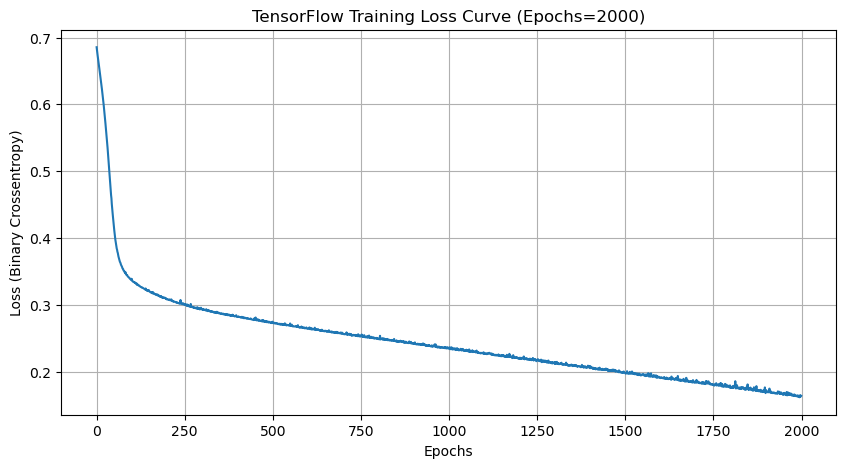

In [44]:
# --- 8. VISUALIZATION (Equivalent to model.loss_curve_ plot) ---

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'])
plt.title(f'TensorFlow Training Loss Curve (Epochs={EPOCHS})')
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.grid(True)
plt.show()